# Chapter 9: The Oracle Problem
Evaluate probability forecasts against the same synthetic binary events.
Calibration, discrimination and sharpness are different properties.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
rng=begin(9); p=rng.beta(2,4,6000); outcomes=rng.binomial(1,p)
over=np.clip(.5+1.6*(p-.5),.01,.99); forecasts={'Calibrated':p,'Overconfident':over,'Base rate':np.repeat(1/3,len(p))}

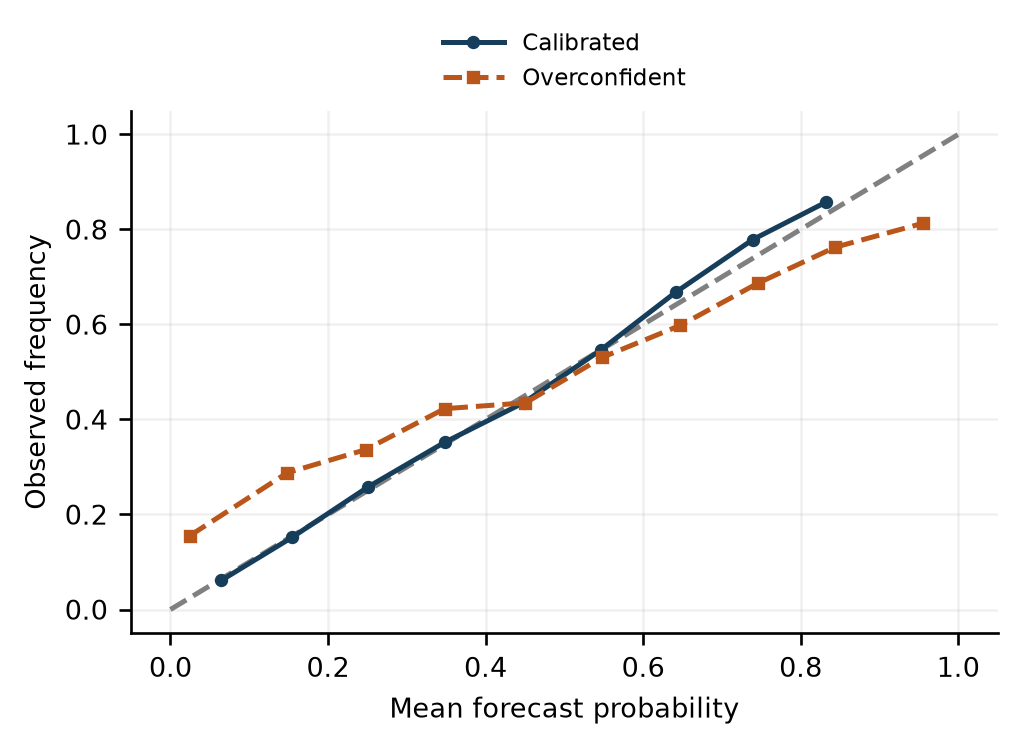

In [2]:
plt.figure(); plt.plot([0,1],[0,1],'--',color='.5')
for label,pred in list(forecasts.items())[:2]:
    xs=[]; ys=[]
    for lo in np.arange(0,1,.1):
        mask=(pred>=lo)&(pred<lo+.1)
        if mask.sum()>20: xs.append(pred[mask].mean()); ys.append(outcomes[mask].mean())
    plt.plot(xs,ys,'o-',label=label)
plt.xlabel('Mean forecast probability'); plt.ylabel('Observed frequency'); plt.legend(fontsize=7)
save(9,1,'Calibration requires repeated outcomes','Reliability curves from 6,000 synthetic events. Only bins with more than twenty observations are shown.','### Calibration, Accuracy, and Resolution')

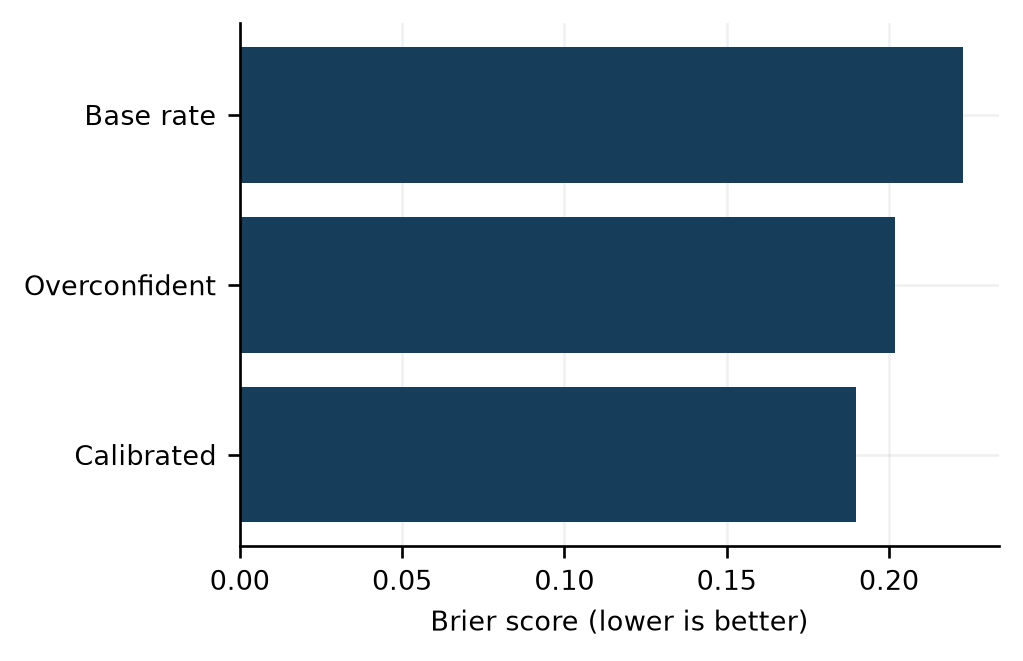

In [3]:
scores={k:brier(v,outcomes) for k,v in forecasts.items()}
plt.figure(); plt.barh(list(scores),list(scores.values())); plt.xlabel('Brier score (lower is better)')
save(9,2,'Keep score on the same questions','Synthetic events scored with mean squared probability error. The constant reference uses the known generating base rate of one third.','### The Brier Score')

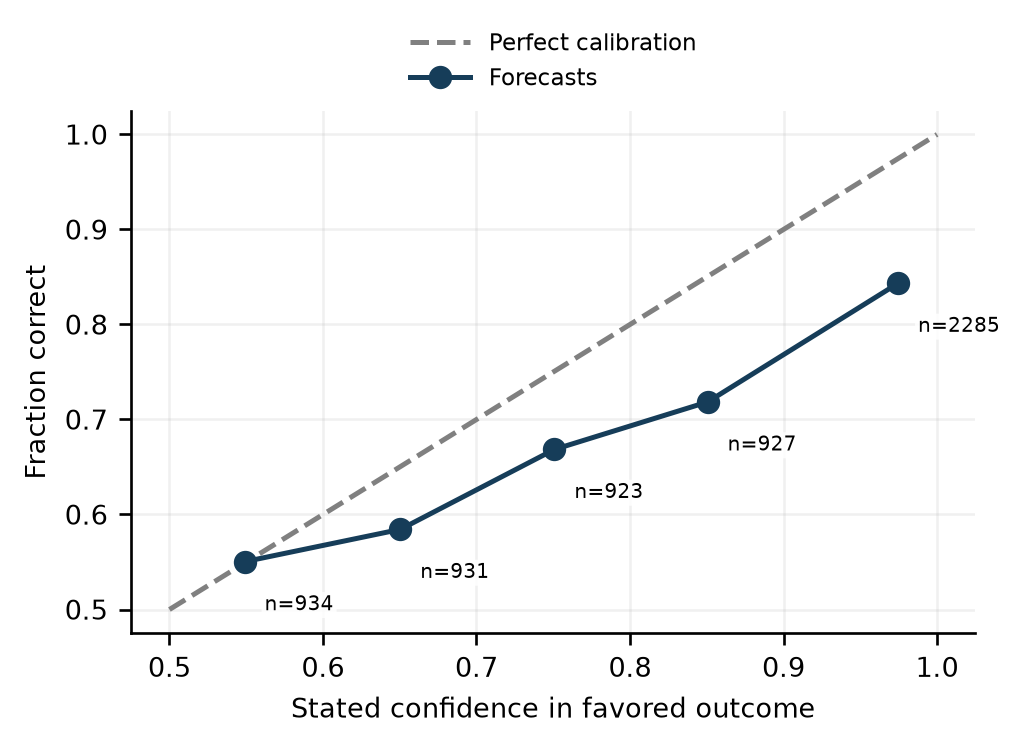

{'Calibrated': 0.1898193937038238, 'Overconfident': 0.20184444039581143, 'Base rate': 0.22288888888888894}


In [4]:
confidence=np.maximum(over,1-over); correct=(over>=.5)==outcomes
xs=[]; ys=[]; counts=[]
for lo in np.arange(.5,1,.1):
    mask=(confidence>=lo)&(confidence<lo+.1)
    xs.append(confidence[mask].mean()); ys.append(correct[mask].mean()); counts.append(mask.sum())
plt.figure(); plt.plot([.5,1],[.5,1],'--',color='.5',label='Perfect calibration'); plt.plot(xs,ys,'o-',label='Forecasts')
for x,y,n in zip(xs,ys,counts): plt.annotate(f'n={n}',(x,y),xytext=(6,-10),textcoords='offset points',fontsize=6,ha='left',va='top',bbox=dict(boxstyle='round,pad=0.15',fc='white',ec='none',alpha=.85))
plt.legend(loc='upper left',frameon=False)
plt.xlabel('Stated confidence in favored outcome'); plt.ylabel('Fraction correct')
save(9,3,'Confidence is a testable claim','Synthetic overconfident forecasts grouped by confidence, with event counts. A single confident success proves little.','### Overconfidence Revisited')
print(scores)

## Limits and exercise
A constant 50% forecast is calibrated only in a population with 50% event frequency.
Resolution measures differences in conditional event rates, not extremeness alone.
Change the generating base rate and observe what happens to constant forecasts.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
CSV event_id,probability,outcome,baseline; probabilities and baseline in [0,1], outcome 0/1 for CLI scoring; retain unresolved cases in the journal, not this scoring file. Each row is one eligible event forecast. Multiple experts require separate aligned forecast columns/files or an explicitly adapted expert_id panel; revisions must be reduced by the predeclared cutoff rule.

Minimal **format illustration**, not sufficient training data:

```csv
event_id,probability,outcome,baseline
E1,0.7,1,0.5
E2,0.2,0,0.5
```

## Explain the mechanism

Proper scores reward honest probabilities over repeated events. Calibration asks whether events given similar probabilities occur at corresponding frequencies. A forecaster can be calibrated yet offer little differentiation among events.

## Work through the arithmetic

For p=[.7,.2] and outcomes [1,0], Brier contributions are .09 and .04, averaging .065. A .5 baseline scores .25 on both. On these two events the difference is -.185, but two events cannot certify skill or calibration.

## Adapt the lesson to reader data

Replace generated p/outcomes with recorded eligible forecasts and resolved outcomes. Retain the fixed event set across comparisons. Do not use the observed full-sample event rate as though it were known when historical baseline forecasts were issued.

For this chapter, settle these questions before fitting: Which events and forecast lead time are shared? Were forecasts recorded before resolution? What baseline was predeclared? Are outcomes missing or selectively reported?

## Interpret the actual lesson outputs

The lesson’s 6,000 events are synthetic and its one-third baseline is known from the generator. The confidence plot annotates counts. A visually diagonal curve does not establish causality, and confidence in the favored outcome differs from probability of the same named event.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `bin_lower,count,mean_probability,frequency,frequency_lower,frequency_upper`.
- `summary.json`: `brier,baseline_brier,events` plus method, interpretation, assumptions, not_done and status.

The scoring adapter requires one resolved outcome per event and uses fixed probability bins. Wilson frequency bounds assume independent events. Preserve unresolved/late forecasts outside this scoring input and report their exclusions in the accompanying analysis.

## Decide what the evidence supports

Lower Brier is better on the same event set. Extreme probabilities are not automatically good resolution. A constant forecast is calibrated only relative to its population event rate. Small or dependent event samples cannot support confident expert rankings.

Without timestamps, report score eligibility as unverified. Without baseline records, use a transparently labeled retrospective comparator, not a claimed predeclared baseline. Missing outcomes stay excluded; investigate whether missingness favors successful predictions.

The applied deliverable must make these items inspectable: `results.csv` columns: `bin_lower,count,mean_probability,frequency,frequency_lower,frequency_upper`; `summary.json` keys: `brier,baseline_brier,events` plus method, interpretation, assumptions, not_done and status. Return per-event and mean Brier, baseline difference, eligibility/exclusion counts, bin means and counts, and limitations of expert comparison.

## Three exercises with worked solutions

### Exercise 1

Forecast .9, outcome 0: Brier?

**Worked solution.** .81, a large penalty for confident error.

### Exercise 2

Every event has true rate .2. Is a constant .5 forecast calibrated?

**Worked solution.** No. In its single forecast bin, observed frequency would approach .2 rather than .5.

### Exercise 3

Expert A scored easy events, B scored difficult ones. Can mean Brier rank skill fairly?

**Worked solution.** Not without adjusting the comparison design; use common events and lead times or explicitly defend a different comparison.

## Business-reader application

Use this request with the skill:

> Use chapter 9 to score probabilities.csv on eligible resolved events, compare the recorded baseline and explain calibration with bin counts rather than unsupported rankings.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [5]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch09.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch09.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(9, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch09-workshop-results.csv', index=False)
_ = (workshop_output/'ch09-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Brier score with reliability bins against a predeclared baseline
Status: passed

Interpretation: Brier 0.1845 against baseline 0.2500 over 200 events (better than the baseline). Reliability bins show the outcome frequency per probability band with Wilson intervals; those intervals assume independent events and express finite-sample uncertainty, not a guarantee of calibration.

Assumptions:
  - Forecasts were issued before the outcomes were known
  - Events are independent enough for binomial bin intervals
  - The baseline was declared before scoring
Not done:
  - No decomposition into reliability, resolution and uncertainty
  - No comparison across forecasters or event types

Evidence:
  brier: 0.1845
  baseline_brier: 0.25
  events: 200

Table: 5 rows, columns ['bin_lower', 'count', 'mean_probability', 'frequency', 'frequency_lower', 'frequency_upper']

 bin_lower  count  mean_probability  frequency  frequency_lower  frequency_upper
       0.0     28             0.161      0.0